In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

ARQUIVO = "Tabela_13_Meio_de_transporte.xlsx"


## Parte 1

In [2]:
df = pd.read_excel(ARQUIVO, sheet_name="Exemplo gráfico Brasil")

df.columns = ["Meio de Transporte", "Branca", "Preta ou Parda", "Indígena"]

df = df.iloc[1:].copy()

for coluna in ["Branca", "Preta ou Parda", "Indígena"]:
    df[coluna] = pd.to_numeric(df[coluna], errors="coerce")

display(df)


,Meio de Transporte,Branca,Preta ou Parda,Indígena
1,A pé,19.4,24.8,37.5
2,Bicicleta,3.2,5.2,5.9
3,Motocicleta ou Mototaxi,9.9,14.2,15.4
4,"Automóvel, taxi ou assemelhados",41.8,20.6,15.2
5,Transporte coletivo,25.2,34.6,22.4
6,Outros,0.5,0.6,3.6


## Piechart

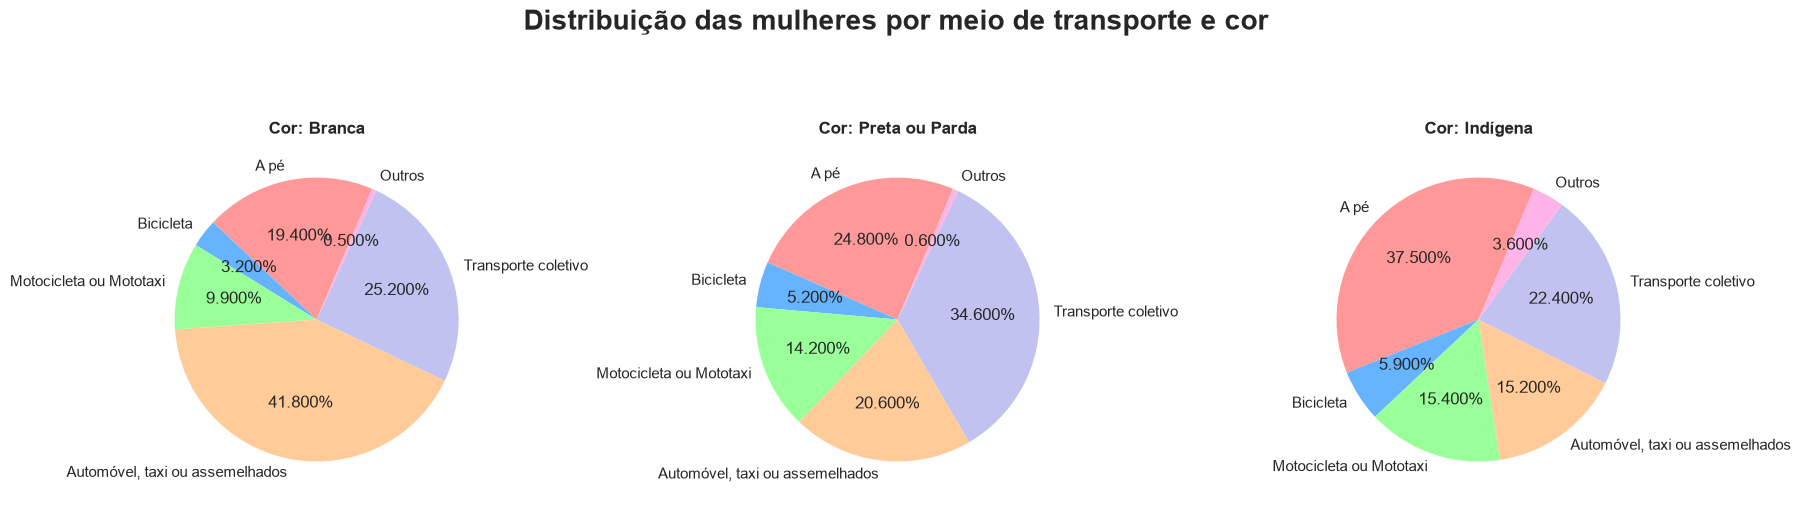

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

cores = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']

grupos = ['Branca', 'Preta ou Parda', 'Indígena']

for i, col in enumerate(grupos):
    axes[i].pie(
        df[col],
        labels=df['Meio de Transporte'],
        autopct='%1.3f%%',
        startangle=67,
        colors=cores,
        wedgeprops={'edgecolor': 'black', 'linewidth': 0},
    )

    axes[i].set_title(
        f'Cor: {col}',
        fontsize=12,
        fontweight='bold'
    )

plt.suptitle(
    'Distribuição das mulheres por meio de transporte e cor',
    fontsize=20,
    fontweight='bold',
)

plt.tight_layout()
plt.savefig('grafico_transporte.png', dpi=300)
plt.show()


In [15]:
for _, linha in df.iterrows():
    transporte = linha["Meio de Transporte"]

    diferenca_branca_preta = linha["Branca"] - linha["Preta ou Parda"]
    diferenca_branca_indigena = linha["Branca"] - linha["Indígena"]
    diferenca_preta_indigena = linha["Preta ou Parda"] - linha["Indígena"]

    print(f"\n{transporte}")
    print(
        f"Brancas - Pretas/Pardas: "
        f"{diferenca_branca_preta:.2f} pontos percentuais"
    )
    print(
        f"Brancas - Indígenas: "
        f"{diferenca_branca_indigena:.2f} pontos percentuais"
    )
    print(
        f"Pretas/Pardas - Indígenas: "
        f"{diferenca_preta_indigena:.2f} pontos percentuais"
    )



A pé
Brancas - Pretas/Pardas: -5.40 pontos percentuais
Brancas - Indígenas: -18.10 pontos percentuais
Pretas/Pardas - Indígenas: -12.70 pontos percentuais

Bicicleta
Brancas - Pretas/Pardas: -2.00 pontos percentuais
Brancas - Indígenas: -2.70 pontos percentuais
Pretas/Pardas - Indígenas: -0.70 pontos percentuais

Motocicleta ou Mototaxi
Brancas - Pretas/Pardas: -4.30 pontos percentuais
Brancas - Indígenas: -5.50 pontos percentuais
Pretas/Pardas - Indígenas: -1.20 pontos percentuais

Automóvel, taxi ou assemelhados
Brancas - Pretas/Pardas: 21.20 pontos percentuais
Brancas - Indígenas: 26.60 pontos percentuais
Pretas/Pardas - Indígenas: 5.40 pontos percentuais

Transporte coletivo
Brancas - Pretas/Pardas: -9.40 pontos percentuais
Brancas - Indígenas: 2.80 pontos percentuais
Pretas/Pardas - Indígenas: 12.20 pontos percentuais

Outros
Brancas - Pretas/Pardas: -0.10 pontos percentuais
Brancas - Indígenas: -3.10 pontos percentuais
Pretas/Pardas - Indígenas: -3.00 pontos percentuais


## PARTE 2

In [16]:
df_br = pd.read_excel(
    ARQUIVO,
    sheet_name="BR GR UF MU",
    header=None
)

display(df_br.head(10))


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,Tabela 13 - Distribuição percentual das mulher...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Brasil, Grande Região, Unidade da Federação e ...",Branca,NaN,NaN,NaN,NaN,NaN,Preta ou Parda,NaN,NaN,NaN,NaN,NaN,Indígena,NaN,NaN,NaN,NaN,NaN
2,NaN,A pé,Bicicleta,Motocicleta ou Mototaxi,"Automóvel, taxi ou assemelhados",Transporte coletivo,Outros,A pé,Bicicleta,Motocicleta ou Mototaxi,"Automóvel, taxi ou assemelhados",Transporte coletivo,Outros,A pé,Bicicleta,Motocicleta ou Mototaxi,"Automóvel, taxi ou assemelhados",Transporte coletivo,Outros
3,Brasil,19.4,3.2,9.9,41.8,25.2,0.5,24.8,5.2,14.2,20.6,34.6,0.6,37.5,5.9,15.4,15.2,22.4,3.6
4,Norte,15.2,5.9,24.5,35.1,17.9,1.3,21.3,8.6,27.7,19.5,20.8,2.1,46.8,4.8,19.2,9.5,9.1,10.6
5,Nordeste,24.9,2.6,19.9,31.6,20.5,0.5,31.7,4.1,20.8,16.9,26,0.6,42,4.2,19.4,13.1,20.6,0.7
6,Sudeste,18.5,2.7,7.1,40.4,30.8,0.5,23,4.5,7,19.5,45.5,0.5,26.2,5.6,5.9,22.3,39.4,0.6
7,Sul,20.8,3.5,7.3,48,20,0.5,24,5.5,8.6,29.2,32.2,0.5,31.1,3.1,5.7,22.8,36.4,1
8,Centro-oeste,12.3,4.9,15,49,18.2,0.4,16.1,7.7,18.3,29.4,28,0.4,24.5,16.2,17.5,18.3,22.9,0.7
9,Rondônia,11.7,7.2,36.7,39.3,4.5,0.6,14.8,12.8,39.9,25.5,6.6,0.4,36.3,17.8,29.9,13.4,1.9,0.6


### 1

In [ ]:
estados = [
    "Rondônia", "Acre", "Amazonas", "Roraima", "Pará", "Amapá",
    "Tocantins", "Maranhão", "Piauí", "Ceará", "Rio Grande do Norte",
    "Paraíba", "Pernambuco", "Alagoas", "Sergipe", "Bahia",
    "Minas Gerais", "Espírito Santo", "Rio de Janeiro", "São Paulo",
    "Paraná", "Santa Catarina", "Rio Grande do Sul", "Mato Grosso do Sul",
    "Mato Grosso", "Goiás", "Distrito Federal"
]

dados_estados = dados[dados["Local"].isin(estados)].copy()

display(dados_estados)

,Local,Branca - A pé,Branca - Bicicleta,Branca - Motocicleta ou Mototaxi,"Branca - Automóvel, taxi ou assemelhados",Branca - Transporte coletivo,Branca - Outros,Preta ou Parda - A pé,Preta ou Parda - Bicicleta,Preta ou Parda - Motocicleta ou Mototaxi,"Preta ou Parda - Automóvel, taxi ou assemelhados",Preta ou Parda - Transporte coletivo,Preta ou Parda - Outros,Indígena - A pé,Indígena - Bicicleta,Indígena - Motocicleta ou Mototaxi,"Indígena - Automóvel, taxi ou assemelhados",Indígena - Transporte coletivo,Indígena - Outros
9,Rondônia,11.7,7.2,36.7,39.3,4.5,0.6,14.8,12.8,39.9,25.5,6.6,0.4,36.3,17.8,29.9,13.4,1.9,0.6
10,Acre,14.8,8.9,27.0,39.4,9.2,0.6,20.0,13.0,29.5,24.7,11.6,1.2,56.7,1.9,16.5,11.4,6.8,6.7
11,Amazonas,13.9,2.0,14.3,37.2,30.1,2.5,20.9,2.5,20.4,18.9,33.3,4.0,49.0,3.6,17.5,6.3,8.7,14.9
12,Roraima,11.6,5.8,20.2,54.3,7.3,0.8,14.6,7.9,25.9,40.6,9.8,1.2,38.6,6.6,25.4,20.6,7.3,1.4
13,Pará,17.5,6.4,25.8,26.6,22.2,1.5,23.7,9.1,28.7,13.5,22.8,2.2,45.7,5.9,18.5,8.2,16.9,4.7
14,Amapá,14.1,7.9,11.4,48.3,17.1,1.2,20.4,12.2,13.1,34.3,18.5,1.4,53.0,NaN,2.4,10.4,10.3,24.0
15,Tocantins,15.9,7.0,28.1,41.8,6.9,0.3,22.0,11.1,33.2,23.2,10.2,0.3,51.4,7.0,19.7,11.7,8.7,1.4
16,Maranhão,21.0,3.9,29.8,27.5,17.2,0.5,29.4,5.4,31.9,14.0,18.7,0.6,43.7,3.3,29.8,7.3,15.8,NaN
17,Piauí,18.2,3.3,33.8,33.6,10.5,0.5,24.4,5.1,37.6,19.0,13.5,0.4,25.7,6.5,35.3,11.2,21.2,NaN
18,Ceará,20.5,3.2,24.6,30.3,20.9,0.5,27.2,5.0,26.1,15.7,25.6,0.4,34.8,8.0,21.4,11.1,23.7,1.1


In [18]:
dados = df_br.iloc[3:].copy()

modos = [
    "A pé",
    "Bicicleta",
    "Motocicleta ou Mototaxi",
    "Automóvel, taxi ou assemelhados",
    "Transporte coletivo",
    "Outros"
]

racas = [
    "Branca",
    "Preta ou Parda",
    "Indígena"
]

dados.columns = ["Local"] + [
    f"{raca} - {modo}"
    for raca in racas
    for modo in modos
]

for coluna in dados.columns[1:]:
    dados[coluna] = pd.to_numeric(
        dados[coluna],
        errors="coerce"
    )

estados_df = dados[dados["Local"].isin(estados)].copy()

display(estados_df.head())


,Local,Branca - A pé,Branca - Bicicleta,Branca - Motocicleta ou Mototaxi,"Branca - Automóvel, taxi ou assemelhados",Branca - Transporte coletivo,Branca - Outros,Preta ou Parda - A pé,Preta ou Parda - Bicicleta,Preta ou Parda - Motocicleta ou Mototaxi,"Preta ou Parda - Automóvel, taxi ou assemelhados",Preta ou Parda - Transporte coletivo,Preta ou Parda - Outros,Indígena - A pé,Indígena - Bicicleta,Indígena - Motocicleta ou Mototaxi,"Indígena - Automóvel, taxi ou assemelhados",Indígena - Transporte coletivo,Indígena - Outros
9,Rondônia,11.7,7.2,36.7,39.3,4.5,0.6,14.8,12.8,39.9,25.5,6.6,0.4,36.3,17.8,29.9,13.4,1.9,0.6
10,Acre,14.8,8.9,27.0,39.4,9.2,0.6,20.0,13.0,29.5,24.7,11.6,1.2,56.7,1.9,16.5,11.4,6.8,6.7
11,Amazonas,13.9,2.0,14.3,37.2,30.1,2.5,20.9,2.5,20.4,18.9,33.3,4.0,49.0,3.6,17.5,6.3,8.7,14.9
12,Roraima,11.6,5.8,20.2,54.3,7.3,0.8,14.6,7.9,25.9,40.6,9.8,1.2,38.6,6.6,25.4,20.6,7.3,1.4
13,Pará,17.5,6.4,25.8,26.6,22.2,1.5,23.7,9.1,28.7,13.5,22.8,2.2,45.7,5.9,18.5,8.2,16.9,4.7


### 2


In [19]:
coletivo = [
    "Branca - Transporte coletivo",
    "Preta ou Parda - Transporte coletivo",
    "Indígena - Transporte coletivo"
]

estados_df["Média Transporte Coletivo"] = estados_df[coletivo].mean(axis=1)

resultado = estados_df.loc[
    estados_df["Média Transporte Coletivo"].idxmax()
]

print("Estado com maior utilização de transporte coletivo:")
print(resultado["Local"])
print(
    "Média:",
    f"{resultado['Média Transporte Coletivo']:.2f}%"
)


Estado com maior utilização de transporte coletivo:
Rio de Janeiro
Média: 52.23%


### 3


In [ ]:
resultado = estados_df.loc[
    estados_df["Média Transporte Coletivo"].idxmin()
]

print("Estado com menor utilização de transporte coletivo:")
print(resultado["Local"])
print(
    "Média:",
    f"{resultado['Média Transporte Coletivo']:.2f}%"
)


### 4


In [ ]:
municipios = dados[
    dados["Local"].astype(str).str.contains(
        r"\([A-Z]{2}\)$",
        regex=True,
        na=False
    )
].copy()

bicicleta = [
    "Branca - Bicicleta",
    "Preta ou Parda - Bicicleta",
    "Indígena - Bicicleta"
]

municipios["Maior % Bicicleta"] = municipios[bicicleta].max(axis=1)

resultado = municipios.loc[
    municipios["Maior % Bicicleta"].idxmax()
]

print("Cidade com maior percentual de mulheres utilizando bicicleta:")
print(resultado["Local"])
print(
    "Percentual:",
    f"{resultado['Maior % Bicicleta']:.2f}%"
)


### 5


In [ ]:
carro = [
    "Branca - Automóvel, taxi ou assemelhados",
    "Preta ou Parda - Automóvel, taxi ou assemelhados",
    "Indígena - Automóvel, taxi ou assemelhados"
]

municipios["Maior % Carro"] = municipios[carro].max(axis=1)

resultado = municipios.loc[
    municipios["Maior % Carro"].idxmax()
]

print("Cidade com maior percentual de mulheres utilizando carro:")
print(resultado["Local"])
print(
    "Percentual:",
    f"{resultado['Maior % Carro']:.2f}%"
)
